In [ ]:
!pip install keras-cv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 51.8 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import matthews_corrcoef, precision_score, recall_score, accuracy_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import keras_cv

from collections import Counter

In [ ]:
from tensorflow.keras.models import Model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Path to dataset in Google Drive
PATH = '/content/drive/MyDrive/'
route_dataset = os.path.join(PATH, 'OCT/')
BATCH_SIZE = 32
img_dim = 224
IMG_SIZE = (img_dim, img_dim)

print("TRAINING AND VALIDATION DATA: ")
train_ds, val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    route_dataset,
    validation_split = 0.3,
    subset = "both",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode = 'categorical',
    shuffle=True,
    seed=200
)

DATOS DE ENTRENAMIENTO Y VALIDACIÓN: 
Found 4908 files belonging to 2 classes.
Using 3436 files for training.
Using 1472 files for validation.


In [ ]:
class_names = val_ds.class_names
print("PROBLEM CLASSES:", class_names)

CLASES DEL PROBLEMA: ['glaucoma', 'normal']


In [ ]:
# Validation split is equally divided into validation and test sets (total 30% of data)
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take((val_batches) // 2)
val_ds = val_ds.skip((val_batches) // 2)

In [ ]:
train_size = train_ds.cardinality().numpy()*BATCH_SIZE
val_size = val_ds.cardinality().numpy()*BATCH_SIZE
test_size = test_ds.cardinality().numpy()*BATCH_SIZE

print(f'Training size: {train_size} images')
print(f'Validation size: {val_size} images')
print(f'Test size: {test_size} images')

Tamaño entrenamiento: 3456 imágenes
Tamaño validación: 736 imágenes
Tamaño prueba: 736 imágenes


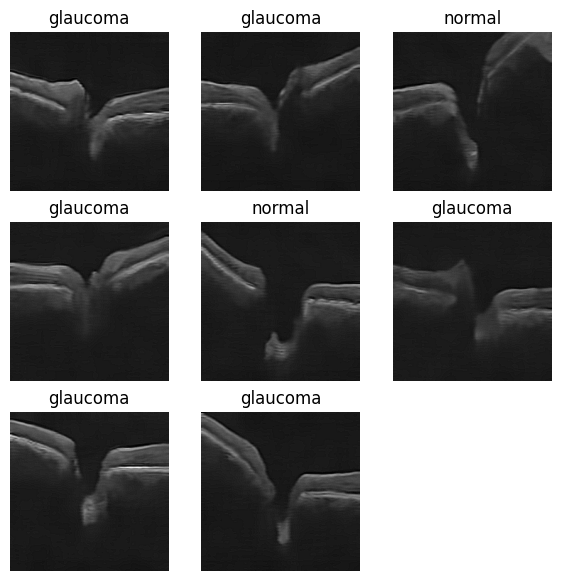

In [ ]:
# Show some data examples, from train dataset
plt.figure(figsize=(7, 7))
for images, labels in train_ds.take(1):
  for i in range(8):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i].numpy()[0].astype("uint8")])
    plt.axis("off")

In [ ]:
# Define AUTOTUNE for performance optimization
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomBrightness((-0.1,0.2)),
  tf.keras.layers.RandomContrast((0.7,1.2)),
  tf.keras.layers.RandomSharpness(factor=(0.5, 1)), 
  tf.keras.layers.RandomRotation(factor = 20/360,  fill_mode='constant'),
  tf.keras.layers.RandomTranslation(height_factor=0.2, width_factor=0.2, fill_mode='constant'),
])

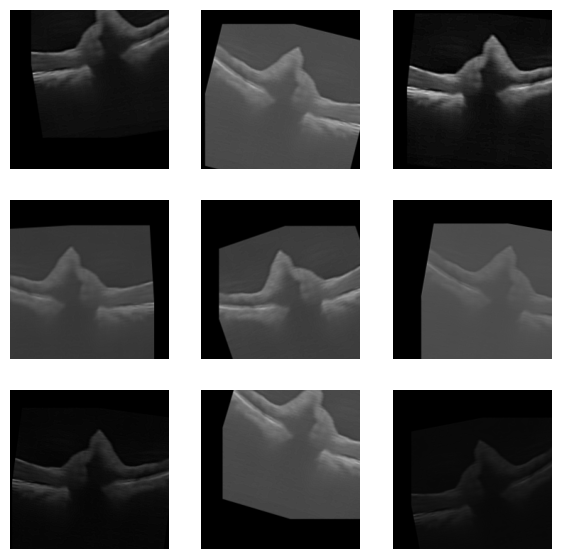

In [ ]:
import random

for image, _ in train_dataset.take(1):
  plt.figure(figsize=(7, 7))

  first_image = image[random.randint(0,6)]
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
    plt.imshow(augmented_image[0] / 255)
    plt.axis('off')

In [ ]:
IMG_SHAPE = IMG_SIZE + (3,)

# from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
# preprocess_input = tf.keras.applications.xception.preprocess_input
from tensorflow.keras.applications.efficientnet import preprocess_input
# preprocess_input = tf.keras.applications.resnet50.preprocess_input

# base_model = tf.keras.applications.MobileNetV3Large(input_shape=IMG_SHAPE, include_top=False, weights='imagenet', pooling = 'none')
# base_model = tf.keras.applications.Xception(input_shape=IMG_SHAPE, include_top=False, weights='imagenet', pooling='none')
base_model = tf.keras.applications.EfficientNetB1(input_shape=IMG_SHAPE, include_top=False, weights='imagenet', pooling='none')
# base_model = tf.keras.applications.ResNet50(input_shape=IMG_SHAPE, include_top=False, weights='imagenet', pooling = 'none')


27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
image_batch, label_batch = next(iter(train_dataset))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(32, 7, 7, 1280)


In [ ]:
# First training phase: Freezed base model (pretrained)
base_model.trainable = False

In [ ]:
base_model.summary()

Model: "efficientnetb1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 6,575,239 (25.08 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,575,239 (25.08 MB)

In [ ]:
from tensorflow.keras import regularizers

In [ ]:
# Classification head construction on top of base model

inputs = tf.keras.Input(shape=IMG_SHAPE)
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x= tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(256, kernel_regularizer=regularizers.l2(l2=1e-3))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.Dropout(0.4)(x)
x = tf.keras.layers.Dense(128, kernel_regularizer=regularizers.l2(l2= 1e-3))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.Dropout(0.4)(x)
x = tf.keras.layers.Dense(64, kernel_regularizer=regularizers.l2(l2= 1e-3))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)
x = tf.keras.layers.Dropout(0.4)(x)
outputs = tf.keras.layers.Dense(2, activation = 'softmax')(x)
model = tf.keras.Model(inputs, outputs)

In [ ]:
# Hyperparameters for first training phase
base_learning_rate = 1e-3
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=base_learning_rate, momentum = 0.9),
              loss=tf.keras.losses.CategoricalFocalCrossentropy(from_logits=False),
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb1 (Functional)     │ (None, 7, 7, 1280)     │     6,575,239 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,946,249 (26.50 MB)

 Trainable params: 370,114 (1.41 MB)

 Non-trainable params: 6,576,135 (25.09 MB)

In [ ]:
len(model.trainable_variables)

14

In [ ]:
initial_epochs = 50

In [ ]:
# Training phase with personalized callbacks and without the need of class weights

history = model.fit(train_dataset,
                    epochs=initial_epochs,
                    validation_data=val_dataset,
                    verbose = 2,
                    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)])#,
                    #class_weight = weights)
                    #callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15),
                    #tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-8, min_delta = 0.001,verbose=1 )],


Epoch 1/50
108/108 - 525s - 5s/step - accuracy: 0.5015 - loss: 0.7967 - val_accuracy: 0.6101 - val_loss: 0.7211
Epoch 2/50
108/108 - 66s - 612ms/step - accuracy: 0.5716 - loss: 0.7630 - val_accuracy: 0.6997 - val_loss: 0.7145
Epoch 3/50
108/108 - 20s - 189ms/step - accuracy: 0.5832 - loss: 0.7512 - val_accuracy: 0.7432 - val_loss: 0.7092
Epoch 4/50
108/108 - 20s - 188ms/step - accuracy: 0.6024 - loss: 0.7396 - val_accuracy: 0.7554 - val_loss: 0.7045
Epoch 5/50
108/108 - 13s - 116ms/step - accuracy: 0.6310 - loss: 0.7257 - val_accuracy: 0.7690 - val_loss: 0.7008
Epoch 6/50
108/108 - 21s - 192ms/step - accuracy: 0.6336 - loss: 0.7239 - val_accuracy: 0.7731 - val_loss: 0.6972
Epoch 7/50
108/108 - 20s - 188ms/step - accuracy: 0.6289 - loss: 0.7193 - val_accuracy: 0.7772 - val_loss: 0.6938
Epoch 8/50
108/108 - 21s - 190ms/step - accuracy: 0.6353 - loss: 0.7135 - val_accuracy: 0.7853 - val_loss: 0.6907
Epoch 9/50
108/108 - 13s - 117ms/step - accuracy: 0.6347 - loss: 0.7087 - val_accuracy: 0.

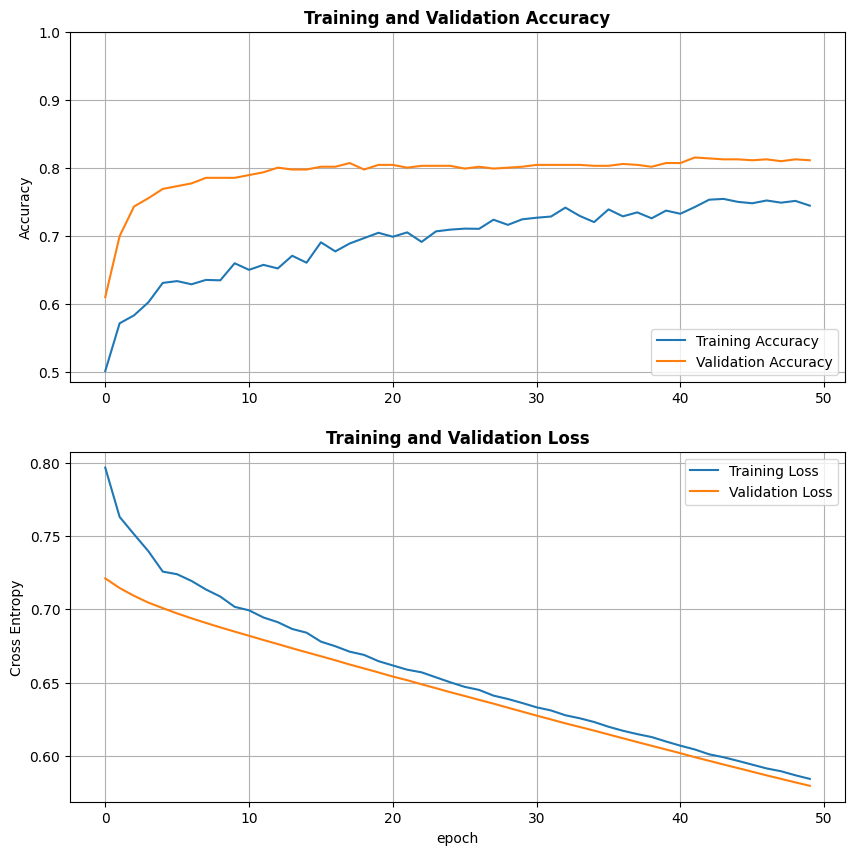

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy', weight= "bold")
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.title('Training and Validation Loss', weight= "bold")
plt.xlabel('epoch')
plt.grid()
plt.show()

# **Fine tuning**

In [ ]:
for i, layer in enumerate(base_model.layers):
    print(f"{i}: {layer.name}")

0: input_layer_1
1: rescaling
2: normalization
3: rescaling_1
4: stem_conv_pad
5: stem_conv
6: stem_bn
7: stem_activation
8: block1a_dwconv
9: block1a_bn
10: block1a_activation
11: block1a_se_squeeze
12: block1a_se_reshape
13: block1a_se_reduce
14: block1a_se_expand
15: block1a_se_excite
16: block1a_project_conv
17: block1a_project_bn
18: block1b_dwconv
19: block1b_bn
20: block1b_activation
21: block1b_se_squeeze
22: block1b_se_reshape
23: block1b_se_reduce
24: block1b_se_expand
25: block1b_se_excite
26: block1b_project_conv
27: block1b_project_bn
28: block1b_drop
29: block1b_add
30: block2a_expand_conv
31: block2a_expand_bn
32: block2a_expand_activation
33: block2a_dwconv_pad
34: block2a_dwconv
35: block2a_bn
36: block2a_activation
37: block2a_se_squeeze
38: block2a_se_reshape
39: block2a_se_reduce
40: block2a_se_expand
41: block2a_se_excite
42: block2a_project_conv
43: block2a_project_bn
44: block2b_expand_conv
45: block2b_expand_bn
46: block2b_expand_activation
47: block2b_dwconv
48

In [ ]:
base_model.trainable = True

In [ ]:
print("Number of layers in the base model: ", len(base_model.layers))

Number of layers in the base model:  340


In [ ]:
print("Number of layers in the base model: ", len(base_model.layers))

fine_tune_at = 0 # Or custom layer

for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

for i, layer in enumerate(base_model.layers):
    print(f"{i} --- {layer.name} --- {layer.trainable}")

Number of layers in the base model:  340
0 --- input_layer_1 --- True
1 --- rescaling --- True
2 --- normalization --- True
3 --- rescaling_1 --- True
4 --- stem_conv_pad --- True
5 --- stem_conv --- True
6 --- stem_bn --- True
7 --- stem_activation --- True
8 --- block1a_dwconv --- True
9 --- block1a_bn --- True
10 --- block1a_activation --- True
11 --- block1a_se_squeeze --- True
12 --- block1a_se_reshape --- True
13 --- block1a_se_reduce --- True
14 --- block1a_se_expand --- True
15 --- block1a_se_excite --- True
16 --- block1a_project_conv --- True
17 --- block1a_project_bn --- True
18 --- block1b_dwconv --- True
19 --- block1b_bn --- True
20 --- block1b_activation --- True
21 --- block1b_se_squeeze --- True
22 --- block1b_se_reshape --- True
23 --- block1b_se_reduce --- True
24 --- block1b_se_expand --- True
25 --- block1b_se_excite --- True
26 --- block1b_project_conv --- True
27 --- block1b_project_bn --- True
28 --- block1b_drop --- True
29 --- block1b_add --- True
30 --- block

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate*0.1),
              loss=tf.keras.losses.CategoricalFocalCrossentropy(from_logits=False),
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb1 (Functional)     │ (None, 7, 7, 1280)     │     6,575,239 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,946,249 (26.50 MB)

 Trainable params: 6,883,298 (26.26 MB)

 Non-trainable params: 62,951 (245.91 KB)

In [ ]:
len(model.trainable_variables)

313

In [ ]:
fine_tune_epochs = 100
total_epochs =  initial_epochs + fine_tune_epochs

history_fine = model.fit(train_dataset,
                         epochs=total_epochs,
                         initial_epoch=history.epoch[-1],
                         validation_data=val_dataset,
                         callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
                                    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8
                                    , min_lr=1e-8, min_delta = 0.01)],
                         verbose = 2)#,
                         #class_weight = weights )

Epoch 50/150
108/108 - 122s - 1s/step - accuracy: 0.7148 - loss: 0.5561 - val_accuracy: 0.8505 - val_loss: 0.5136 - learning_rate: 1.0000e-04
Epoch 51/150
108/108 - 51s - 475ms/step - accuracy: 0.8126 - loss: 0.4868 - val_accuracy: 0.8519 - val_loss: 0.4506 - learning_rate: 1.0000e-04
Epoch 52/150
108/108 - 51s - 476ms/step - accuracy: 0.8286 - loss: 0.4239 - val_accuracy: 0.8668 - val_loss: 0.3920 - learning_rate: 1.0000e-04
Epoch 53/150
108/108 - 82s - 757ms/step - accuracy: 0.8463 - loss: 0.3652 - val_accuracy: 0.8601 - val_loss: 0.3383 - learning_rate: 1.0000e-04
Epoch 54/150
108/108 - 51s - 471ms/step - accuracy: 0.8641 - loss: 0.3129 - val_accuracy: 0.8736 - val_loss: 0.2901 - learning_rate: 1.0000e-04
Epoch 55/150
108/108 - 51s - 471ms/step - accuracy: 0.8591 - loss: 0.2677 - val_accuracy: 0.8750 - val_loss: 0.2468 - learning_rate: 1.0000e-04
Epoch 56/150
108/108 - 51s - 473ms/step - accuracy: 0.8682 - loss: 0.2281 - val_accuracy: 0.8886 - val_loss: 0.2080 - learning_rate: 1.000

In [ ]:
acc2 = acc+history_fine.history['accuracy']
val_acc2 = val_acc+history_fine.history['val_accuracy']

loss2 = loss+history_fine.history['loss']
val_loss2 = val_loss+ history_fine.history['val_loss']

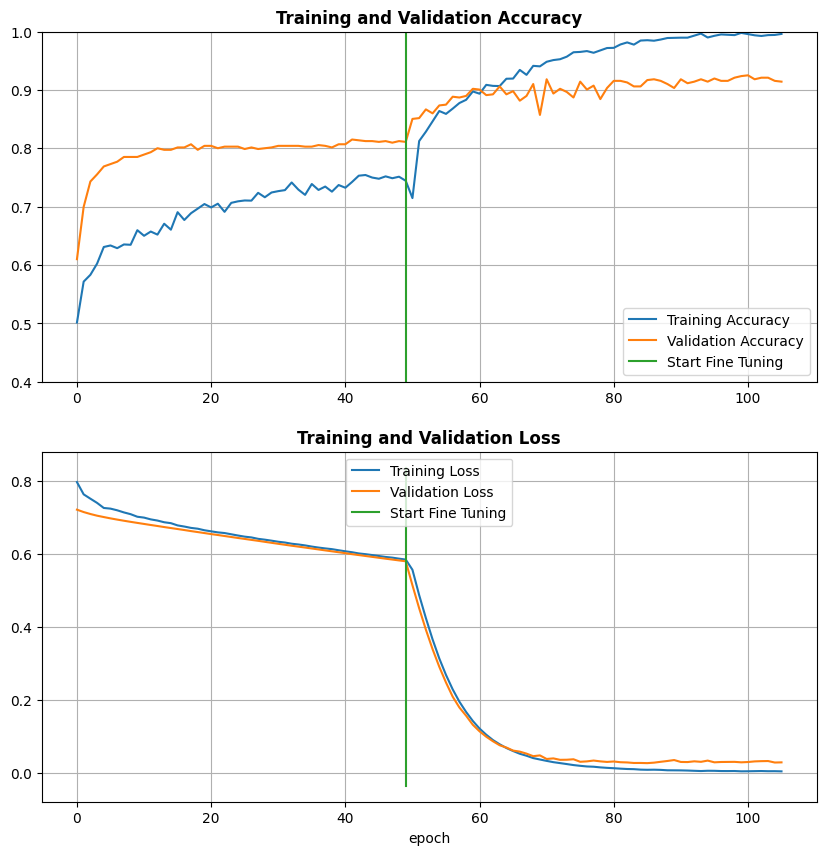

In [ ]:
plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 1)
plt.plot(acc2, label='Training Accuracy')
plt.plot(val_acc2, label='Validation Accuracy')
plt.ylim([0.4, 1])
plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy', weight= "bold")
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(loss2, label='Training Loss')
plt.plot(val_loss2, label='Validation Loss')
plt.plot([initial_epochs-1,initial_epochs-1],
plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper center')
plt.title('Training and Validation Loss', weight= "bold")
plt.xlabel('epoch')
plt.grid()
plt.show()

In [ ]:
def average_voting(model_probabilities):
  avg = 0
  for probs in model_probabilities:
    avg += probs
  avg = avg / len(model_probabilities)
  return avg

def majority_voting(model_probabilities):
  mv = 0
  for probs in model_probabilities:
    mv += probs
  mv = mv / len(model_probabilities)
  return np.round(mv)

In [ ]:
def metric_models(modelos_o_preds, metric = 'prec', X_val=None, y_val=None):
    accuracies = {}

    if len(y_val.shape) > 1 and y_val.shape[1] > 1:
        y_val = np.argmax(y_val, axis=1)

    for i, item in enumerate(modelos_o_preds):
        if callable(getattr(item, "predict", None)):
            predicts = np.argmax(item.predict(X_val), axis=1)
        else:
            predicts = item

        if metric == 'prec':
          measure = precision_score(y_val, predicts)
        elif metric == 'acc':
          measure = accuracy_score(y_val, predicts)
        elif metric == 'recall':
          measure = recall_score(y_val, predicts)
        elif metric == 'f1':
          measure = f1_score(y_val, predicts)
        elif metric == 'mcc':
          measure = matthews_corrcoef(y_val, predicts)
        else:
          raise NameError("Metric specified should be one of the following: acc, prec, recall, f1, mcc")
        accuracies[f"Model_{i+1}"] = measure

    return accuracies

In [ ]:
def abwv_ensemble(models, X_val, Y_val):
    accuracies = metric_models(models, 'prec', X_val, Y_val)
    weights = np.array(list(accuracies.values()))
    weights = weights / np.sum(weights)  
    preds_probas = [model.predict(X_val) for model in models]
    weighted_preds = np.zeros_like(preds_probas[0]) 
    for i, preds in enumerate(preds_probas):
        weighted_preds += preds * weights[i]  
    final_preds = weighted_preds

    return final_preds

In [ ]:
def average_weighted_voting_exponential(models, X_val, Y_val):
  accuracies = metric_models(models, 'prec', X_val, Y_val)
  accuracies2 = np.array(list(accuracies.values()))
  alpha = np.exp(-20 * (1 - accuracies2))
  alpha /= np.sum(alpha)
  preds_probas = [model.predict(X_val) for model in models]
  weighted_preds = np.zeros_like(preds_probas[0])
  for i, preds in enumerate(preds_probas):
    weighted_preds += preds * alpha[i]
  final_preds = weighted_preds

  return final_preds

In [ ]:
def extract_features(model, X):
    feature_extractor = Model(inputs=model.input, outputs=model.layers[-3].output)  
    return feature_extractor.predict(X)

# Meta model training

In [ ]:
RESNET50 = os.path.join(PATH, 'OCT_RESNET50.keras')
MOBILENET = os.path.join(PATH, 'OCT_MOBILENETV3LARGE.keras')
XCEPTION = os.path.join(PATH, 'OCT_XCEPTION.keras')

model1_oct =  tf.keras.models.load_model(RESNET50)
model2_oct =  tf.keras.models.load_model(MOBILENET)
model3_oct =  tf.keras.models.load_model(XCEPTION)


In [ ]:
# ENSEMBLE WITH MLP ON TOP OF CNN FEATURES
model1_sin_softmax = tf.keras.Model(inputs=model1_oct.input,outputs=model1_oct.layers[-3].output)
model2_sin_softmax = tf.keras.Model(inputs=model2_oct.input,outputs=model2_oct.layers[-3].output)
model3_sin_softmax = tf.keras.Model(inputs=model3_oct.input,outputs=model3_oct.layers[-3].output)

model1_sin_softmax.trainable = False
model2_sin_softmax.trainable = False
model3_sin_softmax.trainable = False

In [ ]:
from tensorflow.keras import regularizers

input_common = tf.keras.Input(shape=model1_sin_softmax.input_shape[1:])

out1 = model1_sin_softmax(input_common)
out2 = model2_sin_softmax(input_common)
out3 = model3_sin_softmax(input_common)

fusionCNN = tf.keras.layers.Concatenate()([out1, out2, out3])

x = tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(fusionCNN)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.4)(x)
x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.4)(x)
x = tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = tf.keras.layers.BatchNormalization()(x)
output = tf.keras.layers.Dense(2, activation='softmax')(x)

ensemble_model = Model(inputs=input_common, outputs=output)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-7,
    verbose=1,
    min_delta = 0.01
)

ensemble_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate= 1e-4),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

ensemble_model.summary()

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_18       │ (None, 128)       │ 24,804,608 │ input_layer[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_19       │ (None, 128)       │  3,656,192 │ input_layer[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_20       │ (None, 128)       │ 22,078,376 │ input_layer[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ functional_18[0]… │
│ (Concatenate)       │                   │            │ functional_19[0]… │
│                     │                   │            │ functional_20[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     98,560 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      4,128 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 2)         │         66 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 50,676,490 (193.32 MB)

 Trainable params: 136,482 (533.13 KB)

 Non-trainable params: 50,540,008 (192.79 MB)

In [ ]:
# MLP TRAINING PHASE
card = tf.data.experimental.cardinality(test_dataset).numpy()
print("Total batches:", card)

BATCHES = int(0.3 * card)

val_test_dataset = test_dataset.take(BATCHES)
train_test_dataset = test_dataset.skip(BATCHES)

print("Batches for MLP training:", tf.data.experimental.cardinality(train_test_dataset).numpy())
print("Batches for MLP validation:", tf.data.experimental.cardinality(val_test_dataset).numpy())

Número total de batches: 23
Batches para entrenamiento del MLP superior: 17
Batches para validación del MLP superior: 6


In [ ]:
history_ensemble = ensemble_model.fit(
    train_test_dataset,
    epochs=50,
    validation_data=val_test_dataset,
    verbose = 1,
    callbacks=[reduce_lr],
)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - accuracy: 0.5533 - loss: 0.8752 - val_accuracy: 0.9479 - val_loss: 0.5009 - learning_rate: 1.0000e-04
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 438ms/step - accuracy: 0.7930 - loss: 0.4621 - val_accuracy: 0.9375 - val_loss: 0.3606 - learning_rate: 1.0000e-04
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 443ms/step - accuracy: 0.8651 - loss: 0.3689 - val_accuracy: 0.9375 - val_loss: 0.3080 - learning_rate: 1.0000e-04
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 448ms/step - accuracy: 0.8997 - loss: 0.3213 - val_accuracy: 0.9375 - val_loss: 0.2798 - learning_rate: 1.0000e-04
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 455ms/step - accuracy: 0.9132 - loss: 0.2869 - val_accuracy: 0.9375 - val_loss: 0.2605 - learning_rate: 1.0000e-04
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 462ms/step - accuracy: 0.9203 - loss: 0.2932 - val_accuracy: 0.9375 - val_loss: 0.2489 - learning_rate: 1.0000e-04
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 470ms/step - accuracy: 0.

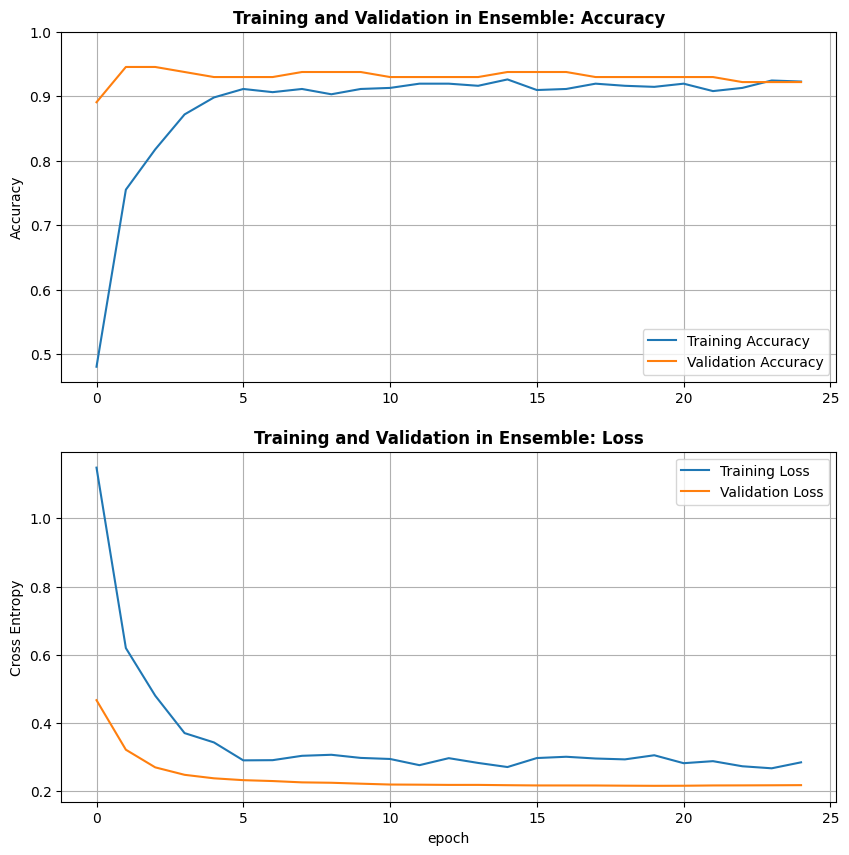

In [ ]:
acc = history_ensemble.history['accuracy']
val_acc = history_ensemble.history['val_accuracy']

loss = history_ensemble.history['loss']
val_loss = history_ensemble.history['val_loss']

plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation in Ensemble: Accuracy', weight= "bold")
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
#plt.ylim([0,1.0])
plt.title('Training and Validation in Ensemble: Loss', weight= "bold")
plt.xlabel('epoch')
plt.grid()
splt.show()

In [ ]:
# ensemble_model.save('/content/drive/MyDrive/OCT_MLP.keras') 

In [ ]:
pred1 = model1_oct.predict(test_dataset)
pred2 = model2_oct.predict(test_dataset)
pred3 = model3_oct.predict(test_dataset)

23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step


In [ ]:
features1 = extract_features(model1_oct, test_dataset)
features2 = extract_features(model2_oct, test_dataset)
features3 = extract_features(model3_oct, test_dataset)

23/23 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 167ms/step


In [ ]:
y_test = []
X_test = []

for images, labels in test_dataset:
    X_test.append(images)
    y_test.append(labels)

X_test = np.concatenate(X_test)
y_test = np.concatenate(y_test)

In [ ]:
predictions = [pred1,pred2, pred3]
models = [model1_oct, model2_oct, model3_oct]

In [ ]:
# Average voting
AV = average_voting(predictions)
# Majority voting
MV = majority_voting(predictions)
# Average Based Weighting Voting (ABWV)
ABWV = abwv_ensemble(models, X_test, y_test)
# Average Based Weighting Voting (ABWV) versión exponencial
ABWVe = average_weighted_voting_exponential(models, X_test, y_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 165ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 163ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 159ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 156ms/step


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate, GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import make_scorer, f1_score, roc_auc_score, matthews_corrcoef, precision_score, recall_score, accuracy_score

# X_meta_model = np.concatenate([pred1, pred2, pred3], axis=1)
# Y_TEST = np.argmax(y_test, axis=1)
# X_train_meta, X_test_meta, y_train_meta, y_test_meta = train_test_split(X_meta_model, y_test, test_size=0.2, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'mcc': make_scorer(matthews_corrcoef),
    'roc_auc': 'roc_auc'
}

# param_grid = {
#     'C': [0.001, 0.01, 0.1, 1, 10, 100],         
#     'penalty': ['l2'],                        
#     'solver': ['lbfgs', 'liblinear'],          
#     'class_weight': [None, 'balanced'],        
#     'max_iter': [500, 800, 1000]              
# }

# grid_search = GridSearchCV(
#     estimator=meta_model,
#     param_grid=param_grid,
#     cv=5,
#     scoring=scoring,
#     refit='mcc',
#     return_train_score=False
# )

X_meta_model = np.concatenate(predictions, axis=1)
Y_TEST = np.argmax(y_test, axis=1)

X_train_meta, X_test_meta, y_train_meta, y_test_meta = train_test_split(X_meta_model, y_test, test_size=0.2, random_state=42)
y_train_meta = np.argmax(y_train_meta, axis=1)
y_test_meta = np.argmax(y_test_meta, axis=1)

## Metamodelo SVM.     Mejores parámetros: {'C': 0.01, 'class_weight': None, 'gamma': 'auto', 'kernel': 'rbf'}

meta_model = SVC(random_state=10, C = 0.01, class_weight= None, gamma ='auto', kernel = 'rbf', probability=True)
meta_model.fit(X_meta_model, Y_TEST)

# cv_results = cross_validate(
#     meta_model,
#     X_meta_model,
#     Y_TEST,
#     cv=5,
#     scoring=scoring,
#     return_train_score=False
# )
# Stacking_meta_model = meta_model.predict_proba(X_test_meta)


# results = grid_search.cv_results_
# print("\nPromedios de las métricas de los mejores hiperparámetros:")
# print(f"Accuracy promedio: {results['mean_test_accuracy'][grid_search.best_index_]:.4f}")
# print(f"F1 Score promedio: {results['mean_test_f1'][grid_search.best_index_]:.4f}")
# print(f"Precision promedio: {results['mean_test_precision'][grid_search.best_index_]:.4f}")
# print(f"Recall promedio: {results['mean_test_recall'][grid_search.best_index_]:.4f}")
# print(f"MCC promedio: {results['mean_test_mcc'][grid_search.best_index_]:.4f}")
# print(f"ROC AUC promedio: {results['mean_test_roc_auc'][grid_search.best_index_]:.4f}")

SVC(C=0.01, gamma='auto', probability=True, random_state=10)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

X_meta_model = np.concatenate([pred1, pred2, pred3], axis=1)
X_train_meta, X_test_meta, y_train_meta, y_test_meta = train_test_split(X_meta_model, y_test, test_size=0.2, random_state=42)

# # Metamodelo SVM
# y_train_meta = np.argmax(y_train_meta, axis=1)
# y_test_meta = np.argmax(y_test_meta, axis=1)
# meta_model = SVC(random_state=10, kernel='rbf', probability=True, class_weight='balanced', C = 70)
# meta_model.fit(X_train_meta, y_train_meta)
# Stacking_meta_model = meta_model.predict_proba(X_test_meta)


In [ ]:
Stacking_meta_model = ABWVe

In [ ]:
# # SVM
# etiquetas_predichas = (Stacking_meta_model > 0.5).astype(int)
# etiquetas_predichas_int = np.argmax(etiquetas_predichas, axis=1)
# y_test_int = y_test_meta

In [ ]:
mcc = matthews_corrcoef(etiquetas_predichas_int, y_test_int)
precision = precision_score(etiquetas_predichas_int, y_test_int, average='macro')*100
recall = recall_score(etiquetas_predichas_int, y_test_int, average='macro')*100
exactitud = accuracy_score(etiquetas_predichas_int, y_test_int)*100
f1 = f1_score(etiquetas_predichas_int, y_test_int, average='macro')*100

print("Matthews Correlation Coefficient (MCC):", mcc)
print("Precision: {:.2f} %".format(precision))
print("Recall: {:.2f} %".format(recall))
print("Accuracy: {:.2f} %".format(exactitud))
print("F1-score: {:.2f} %".format(f1))

Coeficiente de correlación de Mathews (MCC): 0.8841571776890502
Precisión: 94.21 %
Recall: 94.21 %
Exactitud: 94.16 %
F1-score: 94.16 %


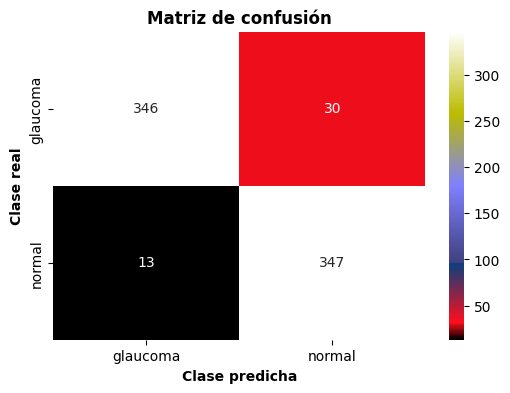

In [ ]:
cm = confusion_matrix(y_test_int, etiquetas_predichas_int, labels=[0., 1.])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="gist_stern", cbar=True,  xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted class", fontweight='bold')
plt.ylabel("Real class", fontweight='bold')
plt.title("Confusion Matrix",fontweight='bold', fontsize = 12)
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc

In [ ]:
y_pred_prob = Stacking_meta_model
#y_pred_prob_int = np.argmax(y_pred_prob, axis=1)
#y_test = np.argmax(y_pred_prob_int, axis=1)
AUC = roc_auc_score(y_test, y_pred_prob)
AUC_macro = roc_auc_score(y_test, y_pred_prob, average="macro", multi_class="ovr")

print("AUC One-vs-Rest:", AUC)
print("AUC Macro:", AUC_macro)

fpr, tpr, THRESOLDS = roc_curve(y_test[:, 0], y_pred_prob[:, 0])
# fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob, multi_class="ovr")
roc_auc = auc(fpr, tpr)

J_scores = tpr - fpr  # Sensibilidad - (1 - Especificidad)
best_threshold = THRESOLDS[np.argmax(J_scores)]
print(f"Best thresold based on ROC curve: {best_threshold:.3f}")

AUC One-vs-Rest: 0.9859411938534278
AUC Macro: 0.9859411938534278
Mejor umbral basado en la curva ROC: 0.537


In [ ]:
# import joblib

# joblib.dump(meta_model, '/content/drive/My Drive/OCT_SVM_PREDS.pkl')

['/content/drive/My Drive/OCT_SVM_PREDS.pkl']

# TESTING INTERNAL CNN TRAINED

In [ ]:
# MODEL = os.path.join(PATH, 'OCT_XCEPTION.keras')
# model =  tf.keras.models.load_model(MODEL)
# model.trainable = False

In [ ]:
loss, accuracy = model.evaluate(test_dataset)
print('Test accuracy :', accuracy)

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.9266 - loss: 0.0247
Test accuracy : 0.9225543737411499


In [ ]:
y_test = []
X_test = []

for images, labels in test_dataset:
    X_test.append(images)
    y_test.append(labels)

X_test = np.concatenate(X_test)
y_test = np.concatenate(y_test)

In [ ]:
predicciones = model.predict(X_test)
etiquetas_predichas = (predicciones >= 0.5).astype(int)

23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step


In [ ]:
etiquetas_predichas_int = np.argmax(etiquetas_predichas, axis=1)
y_test_int = np.argmax(y_test, axis=1)

In [ ]:
mcc = matthews_corrcoef(etiquetas_predichas_int, y_test_int)
precision = precision_score(etiquetas_predichas_int, y_test_int, average='macro')*100
recall = recall_score(etiquetas_predichas_int, y_test_int, average='macro')*100
exactitud = accuracy_score(etiquetas_predichas_int, y_test_int)*100
f1 = f1_score(etiquetas_predichas_int, y_test_int, average='macro')*100

print("Matthews Correlation Coefficient (MCC):", mcc)
print("Precision: {:.2f} %".format(precision))
print("Recall: {:.2f} %".format(recall))
print("Accuracy: {:.2f} %".format(exactitud))
print("F1-score: {:.2f} %".format(f1))

Coeficiente de correlación de Mathews (MCC): 0.8450294250565112
Precisión: 92.25 %
Recall: 92.25 %
Exactitud: 92.26 %
F1-score: 92.25 %


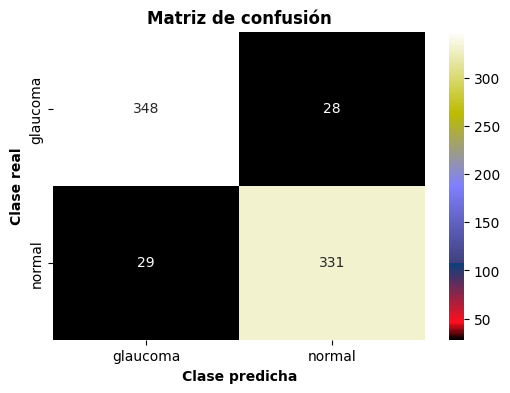

In [ ]:
cm = confusion_matrix(y_test_int, etiquetas_predichas_int, labels=[0., 1.])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="gist_stern", cbar=True,  xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted class", fontweight='bold')
plt.ylabel("Real class", fontweight='bold')
plt.title("Confusion Matrix",fontweight='bold', fontsize = 12)
plt.show()

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc

report = classification_report(y_test_int, etiquetas_predichas_int, target_names=class_names)
print(report)

              precision    recall  f1-score   support

    glaucoma       0.92      0.93      0.92       376
      normal       0.92      0.92      0.92       360

    accuracy                           0.92       736
   macro avg       0.92      0.92      0.92       736
weighted avg       0.92      0.92      0.92       736



In [ ]:
y_pred_prob = model.predict(X_test)
#y_pred_prob_int = np.argmax(y_pred_prob, axis=1)
#y_test = np.argmax(y_pred_prob_int, axis=1)
AUC = roc_auc_score(y_test, y_pred_prob)
AUC_macro = roc_auc_score(y_test, y_pred_prob, average="macro", multi_class="ovr")

print("AUC One-vs-Rest:", AUC)
print("AUC Macro:", AUC_macro)

fpr, tpr, THRESOLDS = roc_curve(y_test[:, 0], y_pred_prob[:, 0])
# fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob, multi_class="ovr")
roc_auc = auc(fpr, tpr)

J_scores = tpr - fpr 
best_threshold = THRESOLDS[np.argmax(J_scores)]
print(f"Best threshold based on ROC curve: {best_threshold:.3f}")
# f1_scores = 2 * (fpr * tpr) / (fpr + tpr + 1e-10)
# best_threshold = thresholds[np.argmax(f1_scores)]

# print(f"AUC-ROC: {AUC:.4f}")
# print(f"Mejor umbral F1: {best_threshold}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step
AUC One-vs-Rest: 0.9724734042553191
AUC Macro: 0.9724734042553191
Mejor umbral basado en la curva ROC: 0.522


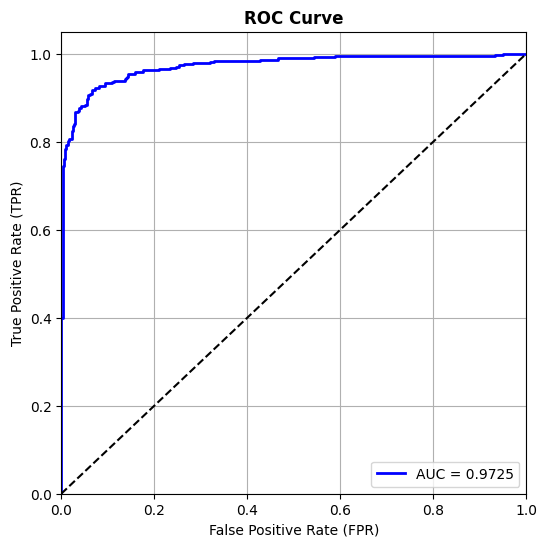

In [ ]:
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve', fontweight='bold')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [ ]:
import cv2

In [ ]:
def compute_gradcam(img, gradcam_model):

    with tf.GradientTape() as tape:
        tape.watch(img)
        conv_output, pred = gradcam_model(img, training=False)
        pred_idx = tf.argmax(pred[0])
        class_channel = pred[:, pred_idx]

    grads = tape.gradient(class_channel, conv_output)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_output[0]

    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return (heatmap, pred)

In [ ]:
# auto adjust number of row,col (subplot) based on n figures
def auto_plot_fig_data(num_figures, verbose=True, fig_scale=2):
    num_cols = int((num_figures)**(1/2))
    num_rows = num_figures // num_cols
    if num_figures % num_cols != 0: num_rows += 1
    if 5 > num_cols < num_rows:
        num_rows, num_cols = num_cols, num_rows
    w = num_cols * fig_scale
    h = num_rows * fig_scale
    if verbose:
        print(f"num_figures: {num_figures}")
        print(f"(num_cols, num_rows): {(num_cols, num_rows)}")
    return {
        "num_cols": num_cols,
        "num_rows": num_rows,
        "w": w,
        "h": h
    }

In [ ]:
def visualize_gradcam(tfdata, gradcam_model, class_names, verbose=True):
    num_figures = sum([1 for _ in tfdata])
    fd = auto_plot_fig_data(num_figures, verbose)
    num_cols = fd['num_cols']
    num_rows = fd['num_rows']

    plt.figure(figsize=(fd['w'], fd['h']))
    for i, (image, label) in enumerate(tfdata):
        plt.subplot(num_rows, num_cols, i+1)

        #Iterate over the batch dimension
        for single_image, single_label in zip(image, label):
            image_tensor = tf.expand_dims(single_image, axis=0) 
            heat_map, pred = compute_gradcam(image_tensor, gradcam_model)
            heat_map = tf.expand_dims(heat_map, axis=-1)  # Assuming Z is 3 for (224, 224, 3) images
            heat_map = tf.image.resize(heat_map, (224, 224))

            plt.imshow(single_image.numpy().astype('uint8'))
            plt.imshow(heat_map, cmap='jet', alpha=0.4)
            plt.title(f"label-{class_names[np.argmax(single_label)]}\npred-{class_names[np.argmax(pred)]}")
            plt.axis("off")

    plt.tight_layout()

In [ ]:
grad_model = tf.keras.Model(
    [model.input], [model.get_layer(name='global_average_pooling2d').input, model.output]
)

In [ ]:
confidence_threshold = 0.9
subset_size = 32  

all_images = []
all_labels = []

for image_batch, label_batch in test_dataset:
    predictions = model.predict(image_batch, verbose=0)

    max_probs = np.max(predictions, axis=1)  
    predicted_labels = np.argmax(predictions, axis=1)  
    true_labels = np.argmax(label_batch, axis=1)  

    mask = (predicted_labels == true_labels) & (max_probs > confidence_threshold)

    selected_images = image_batch.numpy()[mask]
    selected_labels = label_batch.numpy()[mask]

    all_images.extend(selected_images)
    all_labels.extend(selected_labels)

all_images = np.array(all_images)
all_labels = np.array(all_labels)

if len(all_images) < subset_size:
    print(f"Warning: They were just {len(all_images)} images with confidence > {confidence_threshold}. They will all be used.")
    subset_size = len(all_images)  

filtered_images = all_images[:subset_size]
filtered_labels = all_labels[:subset_size]

test_dataset_high_confidence = tf.data.Dataset.from_tensor_slices((filtered_images, filtered_labels))

test_dataset_high_confidence = (
    test_dataset_high_confidence
    .batch(1)  
    .prefetch(tf.data.experimental.AUTOTUNE)
)

print("Expected cardinality:", subset_size)
print("Real cardinality:", test_dataset_high_confidence.cardinality())

for image_batch, label_batch in test_dataset_high_confidence.take(1):
    print("Images shape:", image_batch.shape)  # (1, 224, 224, 3)
    print("Labels shape:", label_batch.shape)

Cardinalidad esperada: 32
Cardinalidad real: tf.Tensor(32, shape=(), dtype=int64)
Imágenes shape: (1, 224, 224, 3)
Etiquetas shape: (1, 2)


In [ ]:
subset_size = 12
test_GRADCAM = test_dataset_high_confidence.skip(1).take(subset_size)

for image_batch, label_batch in test_GRADCAM.take(1):
    print("Images shape:", image_batch.shape)  
    print("Labels shape:", label_batch.shape)

Imagenes shape: (1, 224, 224, 3)
Etiquetas shape: (1, 2)


num_figures: 12
(num_cols, num_rows): (4, 3)


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_716']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


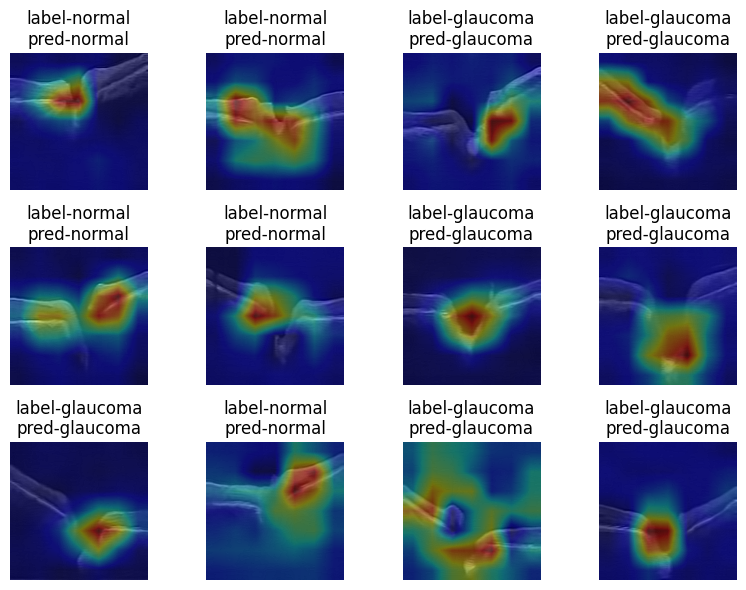

In [ ]:
visualize_gradcam(test_GRADCAM, grad_model, class_names=class_names)

# External validation

In [ ]:
route = 'TRAINING OCT/EXTERNAL VALIDATION/OCT'
external_dir = os.path.join(PATH, route)

In [ ]:
external_dataset = tf.keras.utils.image_dataset_from_directory(external_dir,
                                                                 shuffle=True,
                                                                 batch_size=BATCH_SIZE,
                                                                 image_size=IMG_SIZE,
                                                                 label_mode = 'categorical'
                                                                 )

Found 125 files belonging to 2 classes.


In [ ]:
loss_ext, accuracy_ext = model.evaluate(external_dataset)
print('Test accuracy :', accuracy_ext)
print('Test loss :', loss_ext)

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.8266 - loss: 0.7815
Test accuracy : 0.8320000171661377
Test loss : 0.7194623351097107


In [ ]:
y_external = []
X_external = []

for images, labels in external_dataset:
    X_external.append(images)
    y_external.append(labels)

X_external = np.concatenate(X_external)
y_external = np.concatenate(y_external)

In [ ]:
predicciones_external = model.predict(X_external)
etiquetas_predichas_external = (predicciones_external >= 0.5).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step   


In [ ]:
etiquetas_predichas_ext = np.argmax(etiquetas_predichas_external, axis=1)
y_test_ext = np.argmax(y_external, axis=1)

In [ ]:
mcc = matthews_corrcoef(etiquetas_predichas_ext, y_test_ext)
precision = precision_score(etiquetas_predichas_ext, y_test_ext, average='macro')*100
recall = recall_score(etiquetas_predichas_ext, y_test_ext, average='macro')*100
exactitud = accuracy_score(etiquetas_predichas_ext, y_test_ext)*100
f1 = f1_score(etiquetas_predichas_ext, y_test_ext, average='macro')*100

print("Matthews Correlation Coefficient (MCC):", mcc)

print("Precision: {:.2f} %".format(precision))
print("Recall: {:.2f} %".format(recall))
print("Accuracy: {:.2f} %".format(exactitud))
print("F1-score: {:.2f} %".format(f1))

Coeficiente de correlación de Mathews (MCC): 0.48420012470625223
Precisión: 81.82 %
Recall: 68.42 %
Exactitud: 83.20 %
F1-score: 71.54 %


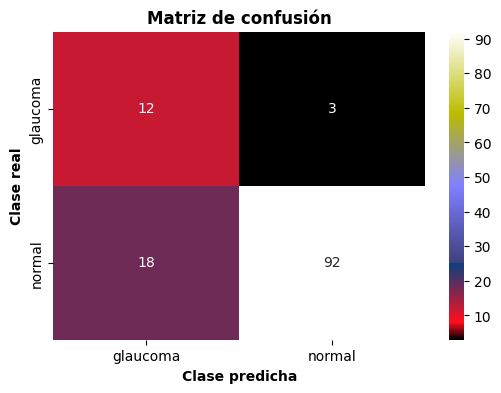

In [ ]:
cm = confusion_matrix(y_test_ext, etiquetas_predichas_ext, labels=[0., 1.])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="gist_stern", cbar=True, xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted class", fontweight='bold')
plt.ylabel("Real class", fontweight='bold')
plt.title("Confusion Matrix",fontweight='bold', fontsize = 12)
plt.show()

In [ ]:
report_ext = classification_report(y_test_ext, etiquetas_predichas_ext, target_names=class_names)
print(report_ext)

              precision    recall  f1-score   support

    glaucoma       0.40      0.80      0.53        15
      normal       0.97      0.84      0.90       110

    accuracy                           0.83       125
   macro avg       0.68      0.82      0.72       125
weighted avg       0.90      0.83      0.85       125



In [ ]:
y_pred_prob = model.predict(X_external)
AUC = roc_auc_score(y_external, predicciones_external)
AUC_macro = roc_auc_score(y_external, predicciones_external, average="macro", multi_class="ovr")

print(f"AUC One-vs-Rest: {AUC:.4f}")
print(f"AUC Macro: {AUC_macro:.4f}")

fpr, tpr, THRESOLD_EXTERNAL = roc_curve(y_external[:, 0], y_pred_prob[:, 0])
roc_auc = auc(fpr, tpr)

J_scores = tpr - fpr  # Sensibilidad - (1 - Especificidad)
best_threshold = THRESOLD_EXTERNAL[np.argmax(J_scores)]
print(f"Mejor umbral basado en la curva ROC: {best_threshold:.3f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step
AUC One-vs-Rest: 0.8927
AUC Macro: 0.8927
Mejor umbral basado en la curva ROC: 0.993


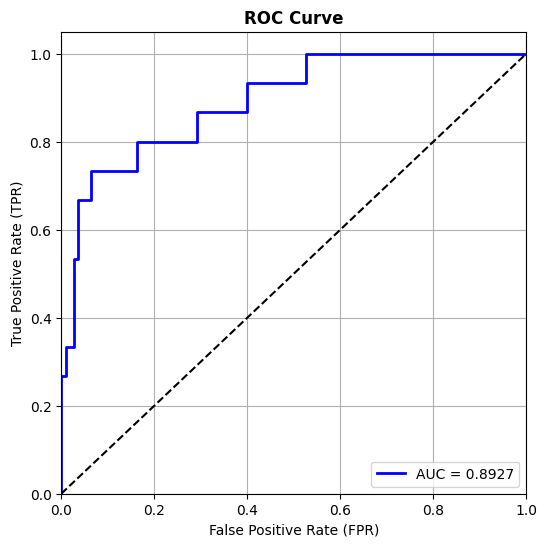

In [ ]:
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve', fontweight='bold')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [ ]:
confidence_threshold = 0.9
subset_size = 32  

all_images = []
all_labels = []

for image_batch, label_batch in external_dataset:
    predictions = model.predict(image_batch, verbose=0)

    max_probs = np.max(predictions, axis=1)  
    predicted_labels = np.argmax(predictions, axis=1)
    true_labels = np.argmax(label_batch, axis=1)  

    mask = (predicted_labels == true_labels) & (max_probs > confidence_threshold)

    selected_images = image_batch.numpy()[mask]
    selected_labels = label_batch.numpy()[mask]

    all_images.extend(selected_images)
    all_labels.extend(selected_labels)

all_images = np.array(all_images)
all_labels = np.array(all_labels)

if len(all_images) < subset_size:
    print(f"Advertencia: Solo se encontraron {len(all_images)} imágenes con confianza > {confidence_threshold}. Se usarán todas.")
    subset_size = len(all_images)  #

filtered_images = all_images[:subset_size]
filtered_labels = all_labels[:subset_size]

external_dataset_high_confidence = tf.data.Dataset.from_tensor_slices((filtered_images, filtered_labels))

external_dataset_high_confidence = (
    external_dataset_high_confidence
    .batch(1)  
    .prefetch(tf.data.experimental.AUTOTUNE)
)

print("Expected cardinality:", subset_size)
print("Real cardinality:", test_dataset_high_confidence.cardinality())

for image_batch, label_batch in test_dataset_high_confidence.take(1):
    print("Images shape:", image_batch.shape)  # (1, 224, 224, 3)
    print("Labels shape:", label_batch.shape)

Cardinalidad esperada: 32
Cardinalidad real: tf.Tensor(32, shape=(), dtype=int64)
Imágenes shape: (1, 224, 224, 3)
Etiquetas shape: (1, 2)


In [ ]:
subset_size = 12
test_GRADCAM2 = external_dataset_high_confidence.skip(1).take(subset_size)

for image_batch, label_batch in test_GRADCAM2.take(1):
    print("Imagenes shape:", image_batch.shape)  
    print("Etiquetas shape:", label_batch.shape)

Imagenes shape: (1, 224, 224, 3)
Etiquetas shape: (1, 2)


num_figures: 12
(num_cols, num_rows): (4, 3)


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_716']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


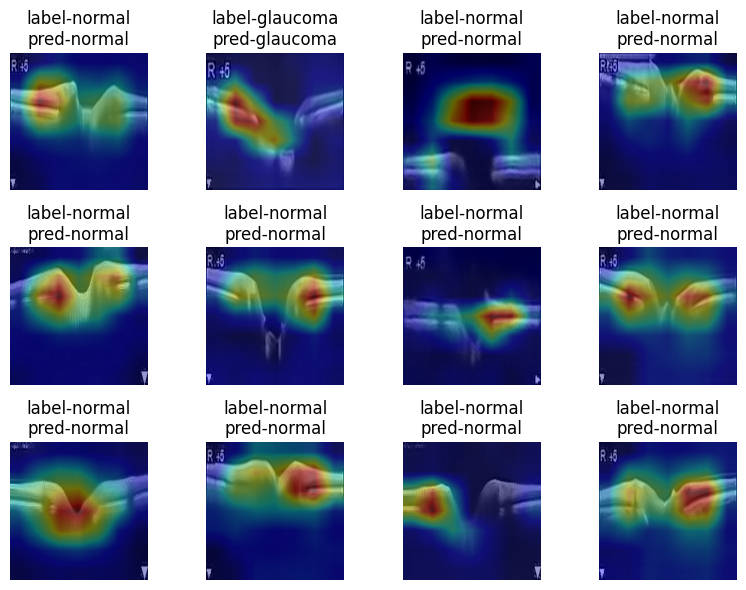

In [ ]:
visualize_gradcam(test_GRADCAM2, grad_model, class_names=class_names)

In [ ]:
# model.save('/content/drive/MyDrive/MODEL_NAME.keras') 